Cek ketersedian gpu nvidia

In [1]:
!nvidia-smi

Sun Jun 21 19:14:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

mengambil dataset yang sudah dibuat dan di

Bisa drag and drop di sidebar dari direktori laptop

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/dataset/data.zip /content

Mounted at /content/gdrive


unzip dataset yang telah dizip dan di copy ke content

In [3]:
!unzip -q /content/data.zip -d /content/custom_data

split dataset

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data/data" --train_pct=0.9

--2026-05-29 13:37:31--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-05-29 13:37:31 (45.4 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 500
Number of annotation files: 500
Images moving to train: 450
Images moving to validation: 50


install framework ultralytics untuk model yolo

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.5 MB/s eta 0:00:00


mengkonfigurasi untuk melakukan training

In [5]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):
    """
    Membuat file data.yaml untuk YOLO dengan dukungan folder test
    """
    # Read class.txt to get class names
    if not os.path.exists(path_to_classes_txt):
        print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
        return

    with open(path_to_classes_txt, 'r') as f:
        classes = []
        for line in f.readlines():
            if len(line.strip()) == 0:
                continue
            classes.append(line.strip())
    number_of_classes = len(classes)

    # CEK STRUKTUR FOLDER
    base_path = '/content/custom_data/data'

    # Cek apakah ada folder test
    test_path = os.path.join(base_path, 'test')
    has_test = os.path.exists(test_path)

    # Create data dictionary
    data = {
        'path': base_path,                    # path utama
        'train': 'train/images',              # train set
        'val': 'validation/images',           # validation set
        'nc': number_of_classes,
        'names': classes
    }

    # Tambahkan test jika ada
    if has_test:
        data['test'] = 'test/images'          # test set (untuk prediksi)
        print(f'📁 Folder test ditemukan di: {test_path}')
    else:
        print('ℹ️  Tidak ada folder test, hanya train dan validation')

    # Write data to YAML file
    with open(path_to_data_yaml, 'w') as f:
        yaml.dump(data, f, sort_keys=False)

    print(f'✅ Created config file at {path_to_data_yaml}')
    print(f'📊 Jumlah kelas: {number_of_classes}')
    print(f'📋 Kelas: {classes}')

    return data

# ============================================
# EKSEKUSI
# ============================================
path_to_classes_txt = '/content/custom_data/data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

# Buat file data.yaml
create_data_yaml(path_to_classes_txt, path_to_data_yaml)

# Tampilkan isi file
print('\n📄 File contents:\n')
!cat /content/data.yaml

# ============================================
# CEK STRUKTUR FOLDER LENGKAP
# ============================================
print('\n📁 CEK STRUKTUR FOLDER:')
!ls -la /content/custom_data/data
!echo "\n📂 Train images:"
!ls /content/custom_data/data/train/images | head -5
!echo "\n📂 Validation images:"
!ls /content/custom_data/data/validation/images/ | head -5

# Cek folder test jika ada
if os.path.exists('/content/custom_data/data/test'):
    print("\n📂 Test images:")
    !ls /content/custom_data/data/test/images | head -5
else:
    print("\nℹ️  Tidak ada folder test")

📁 Folder test ditemukan di: /content/custom_data/data/test
✅ Created config file at /content/data.yaml
📊 Jumlah kelas: 6
📋 Kelas: ['apel_segar', 'apel_tidak_segar', 'pisang_segar', 'pisang_tidak_segar', 'stroberi_segar', 'stroberi_tidak_segar']

📄 File contents:

path: /content/custom_data/data
train: train/images
val: validation/images
nc: 6
names:
- apel_segar
- apel_tidak_segar
- pisang_segar
- pisang_tidak_segar
- stroberi_segar
- stroberi_tidak_segar
test: test/images

📁 CEK STRUKTUR FOLDER:
total 36
drwxr-xr-x 6 root root 4096 Jun 21 19:16 .
drwxr-xr-x 3 root root 4096 Jun 21 19:15 ..
-rw-r--r-- 1 root root  100 Jun 21 18:54 classes.txt
-rw-r--r-- 1 root root  356 Jun 21 18:33 data.yaml
drwxr-xr-x 2 root root 4096 Jun 21 19:16 .ipynb_checkpoints
-rw-r--r-- 1 root root  985 Jun 21 18:33 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Jun 21 18:34 test
drwxr-xr-x 4 root root 4096 Jun 21 18:34 train
drwxr-xr-x 4 root root 4096 Jun 21 18:34 validation
\n📂 Train images:
apel_segar-102

In [6]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=400 imgsz=640 \
    hsv_h=0.02 hsv_s=0.8 hsv_v=0.4 \
    degrees=15.0 translate=0.2 scale=0.5 \
    fliplr=0.5 flipud=0.0 mosaic=1.0 mixup=0.1

from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.4.75 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=400, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, for

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

test model

In [10]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=/content/custom_data/data/validation/images save=True

Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs

image 1/120 /content/custom_data/data/validation/images/apel_segar-10_png.rf.949766be0ccc2b7bdbc89739a03c9b2e.jpg: 640x640 4 apel_segars, 15.6ms
image 2/120 /content/custom_data/data/validation/images/apel_segar-110_png.rf.f057a573707fdcb2672ebe46558be773.jpg: 640x640 1 apel_segar, 15.5ms
image 3/120 /content/custom_data/data/validation/images/apel_segar-115_png.rf.df970764b3310118f1cf45cd42d42d4b.jpg: 640x640 1 apel_segar, 15.4ms
image 4/120 /content/custom_data/data/validation/images/apel_segar-127_png.rf.7436a00e0884c97ec2655e4225e56dd2.jpg: 640x640 1 apel_segar, 15.4ms
image 5/120 /content/custom_data/data/validation/images/apel_segar-12_png.rf.5b974b3346ede0aa897c3c71e2994a0c.jpg: 640x640 4 apel_segars, 15.5ms
image 6/120 /content/custom_data/data/validation/images/apel_segar-137_png.rf.c04277607a6a46dd5e23d03c75418

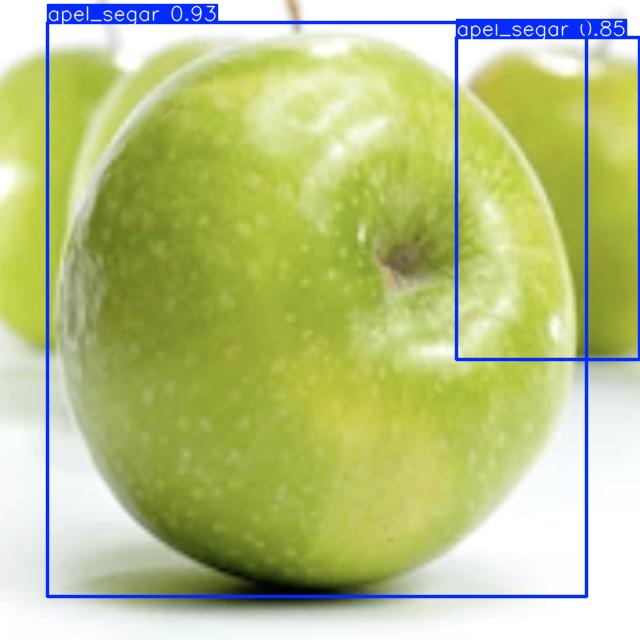

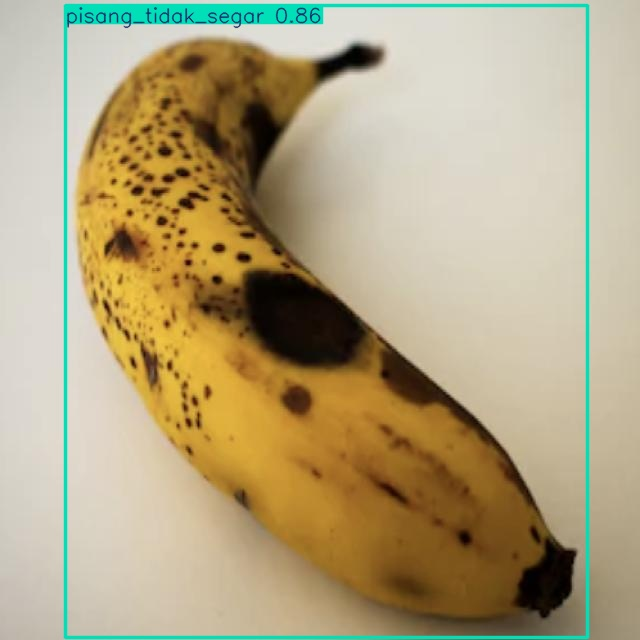

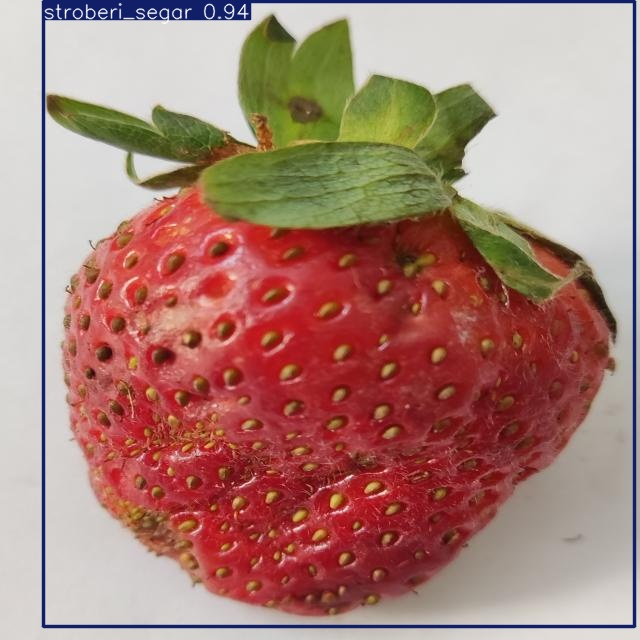

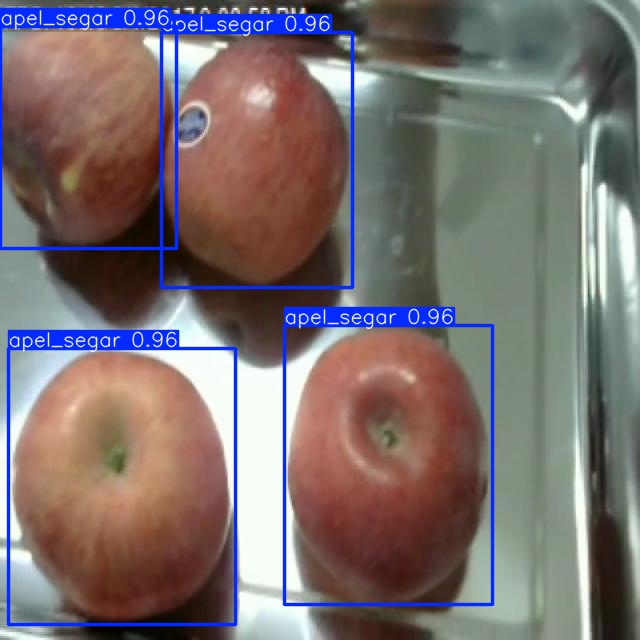

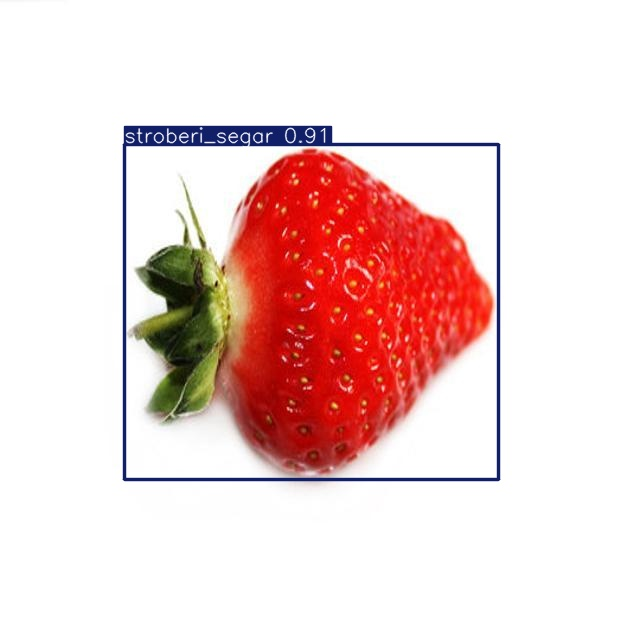

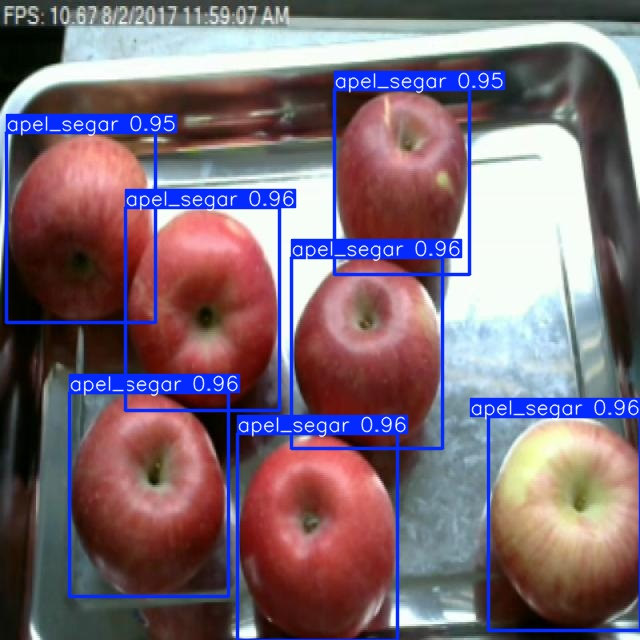

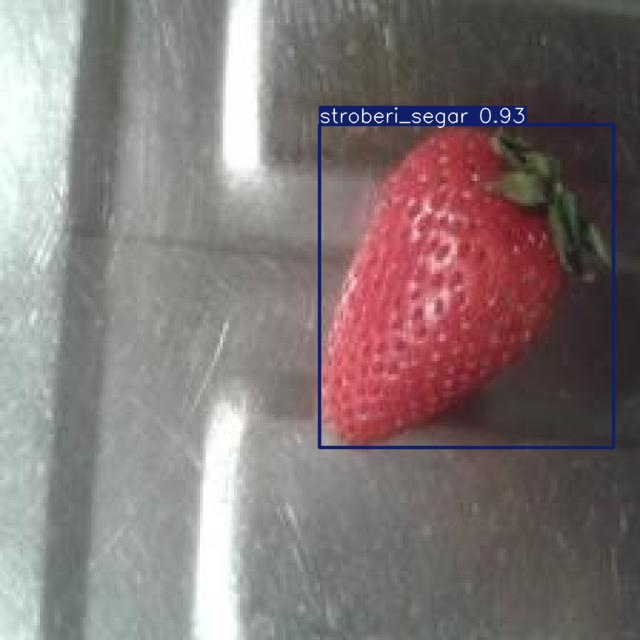

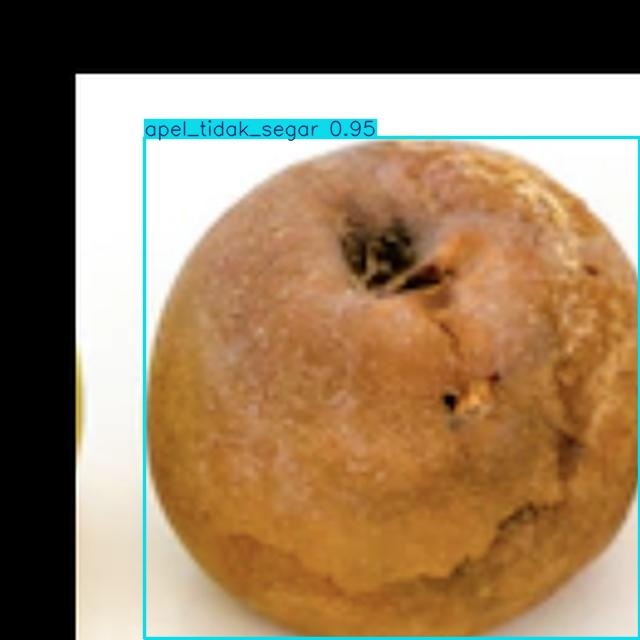

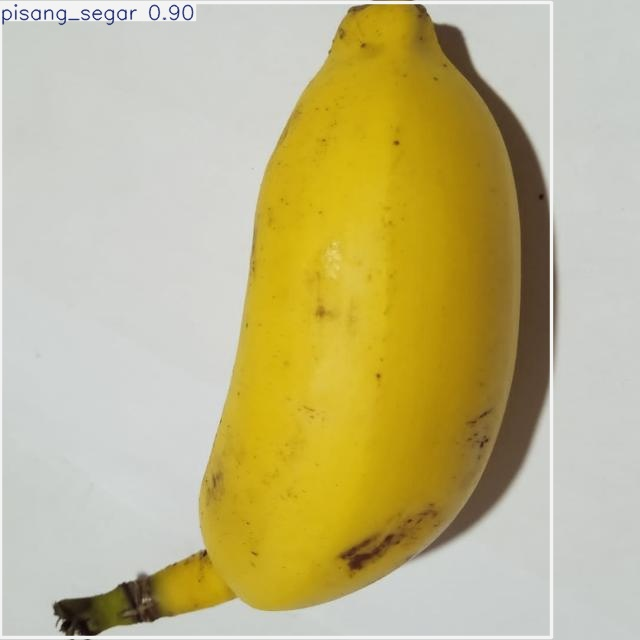

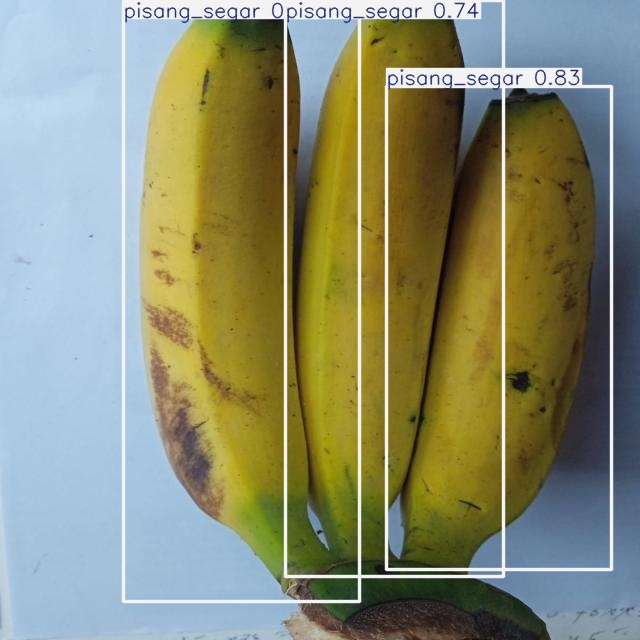

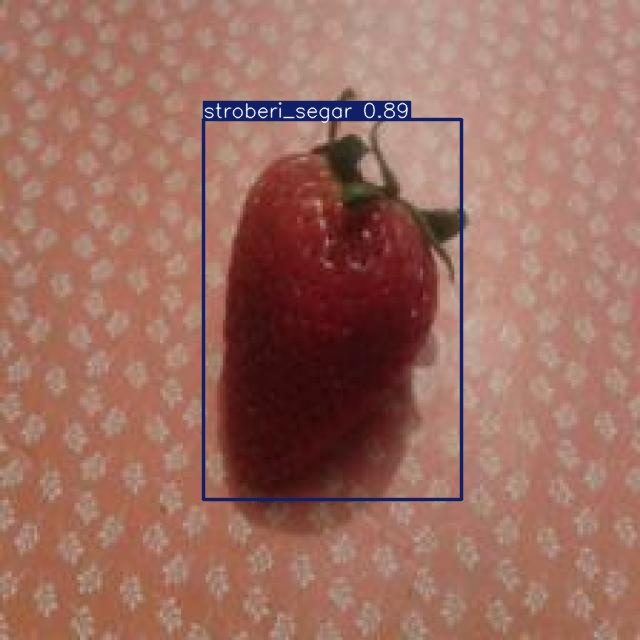

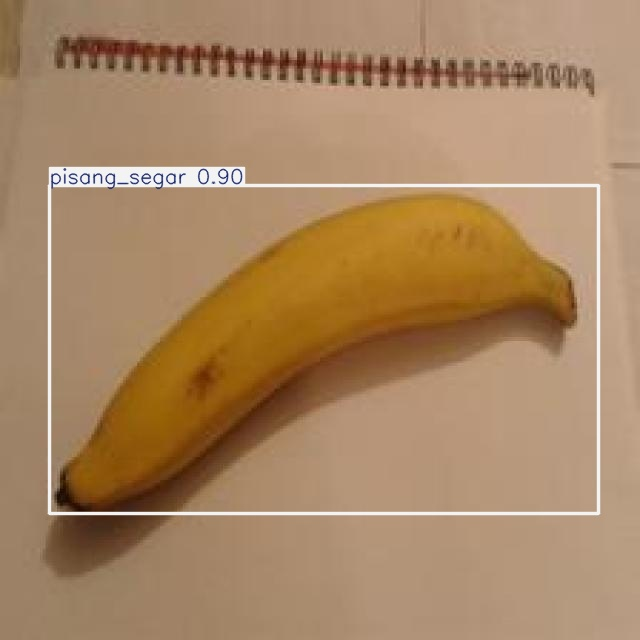

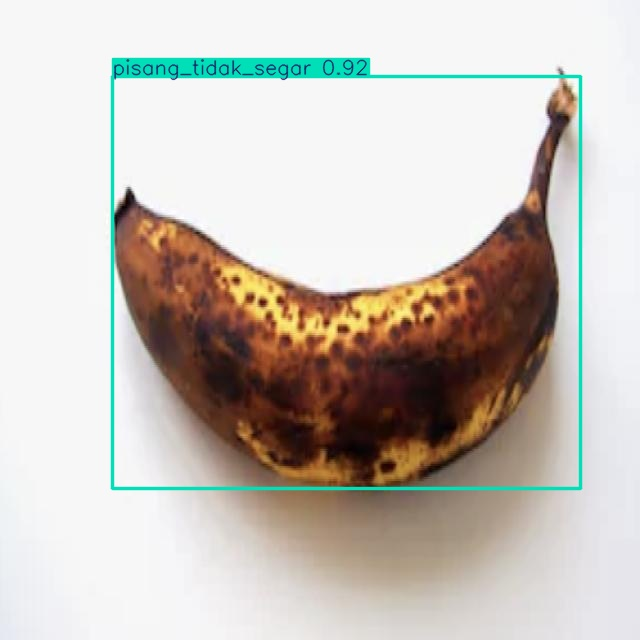

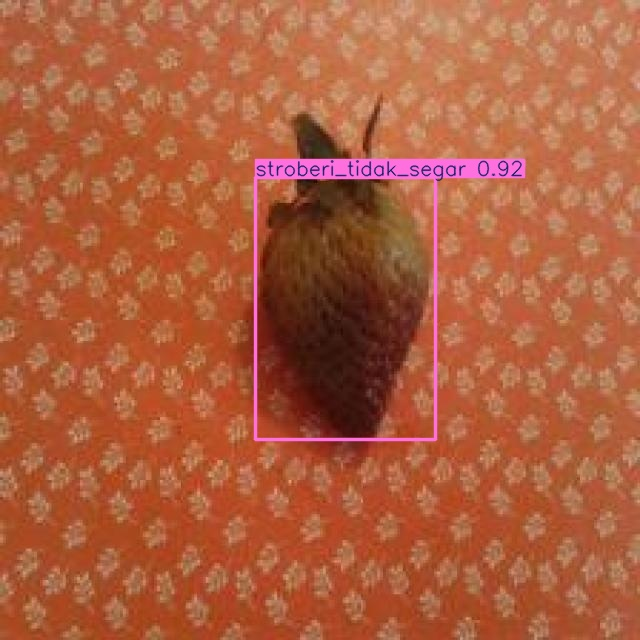

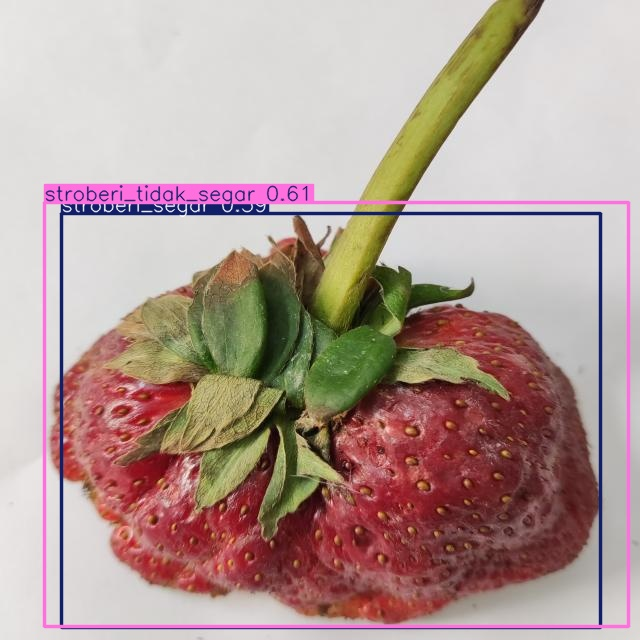

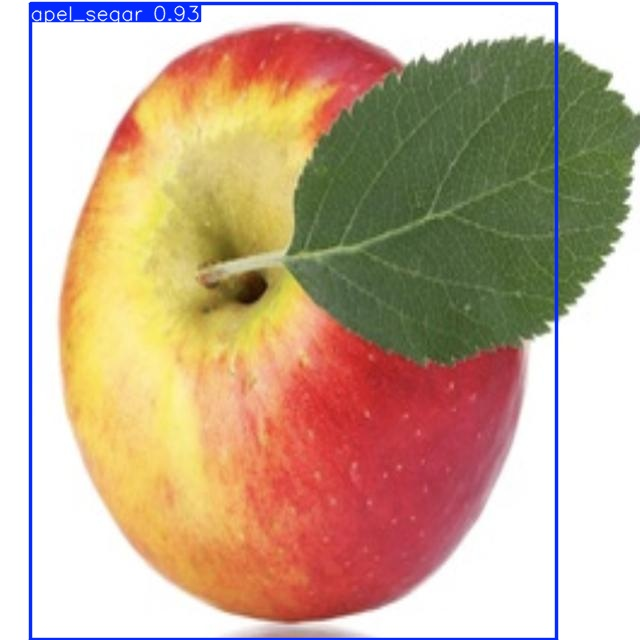

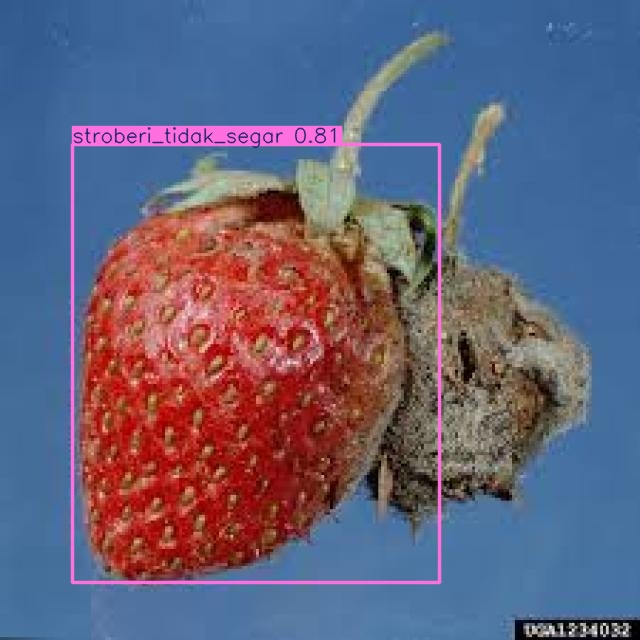

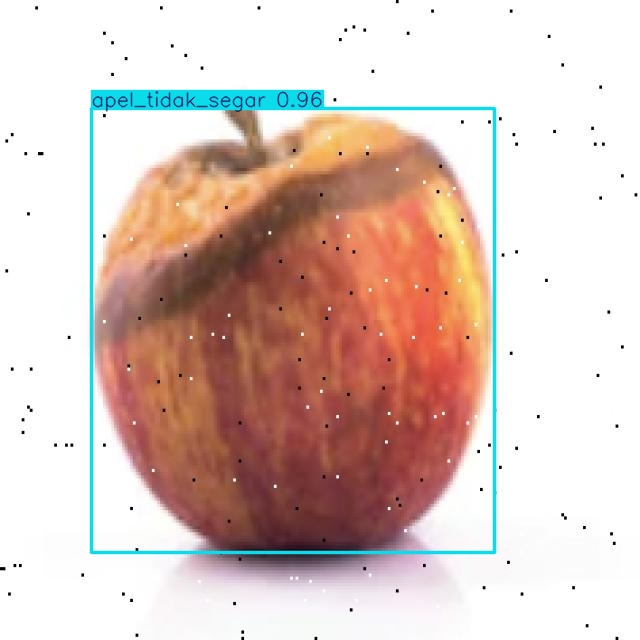

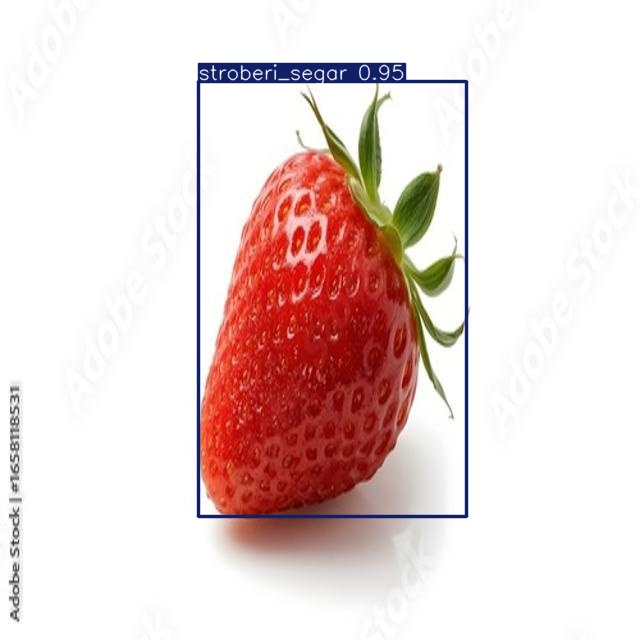

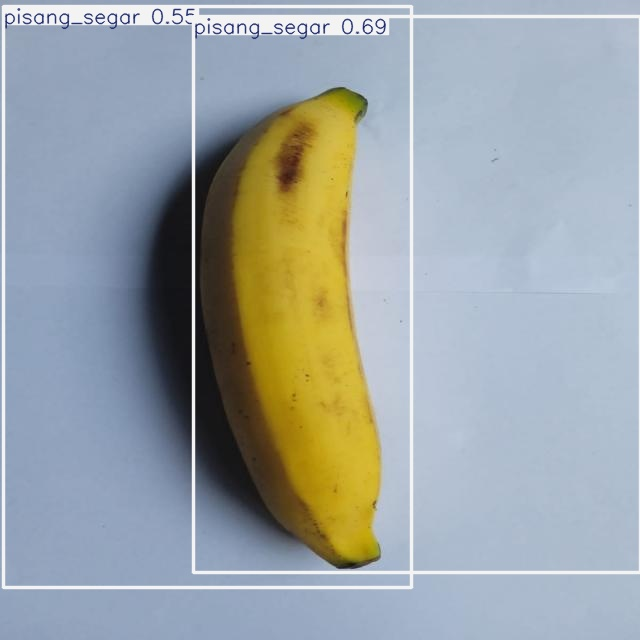

In [11]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:20]:
  display(Image(filename=image_path, height=400))
  print('\n')


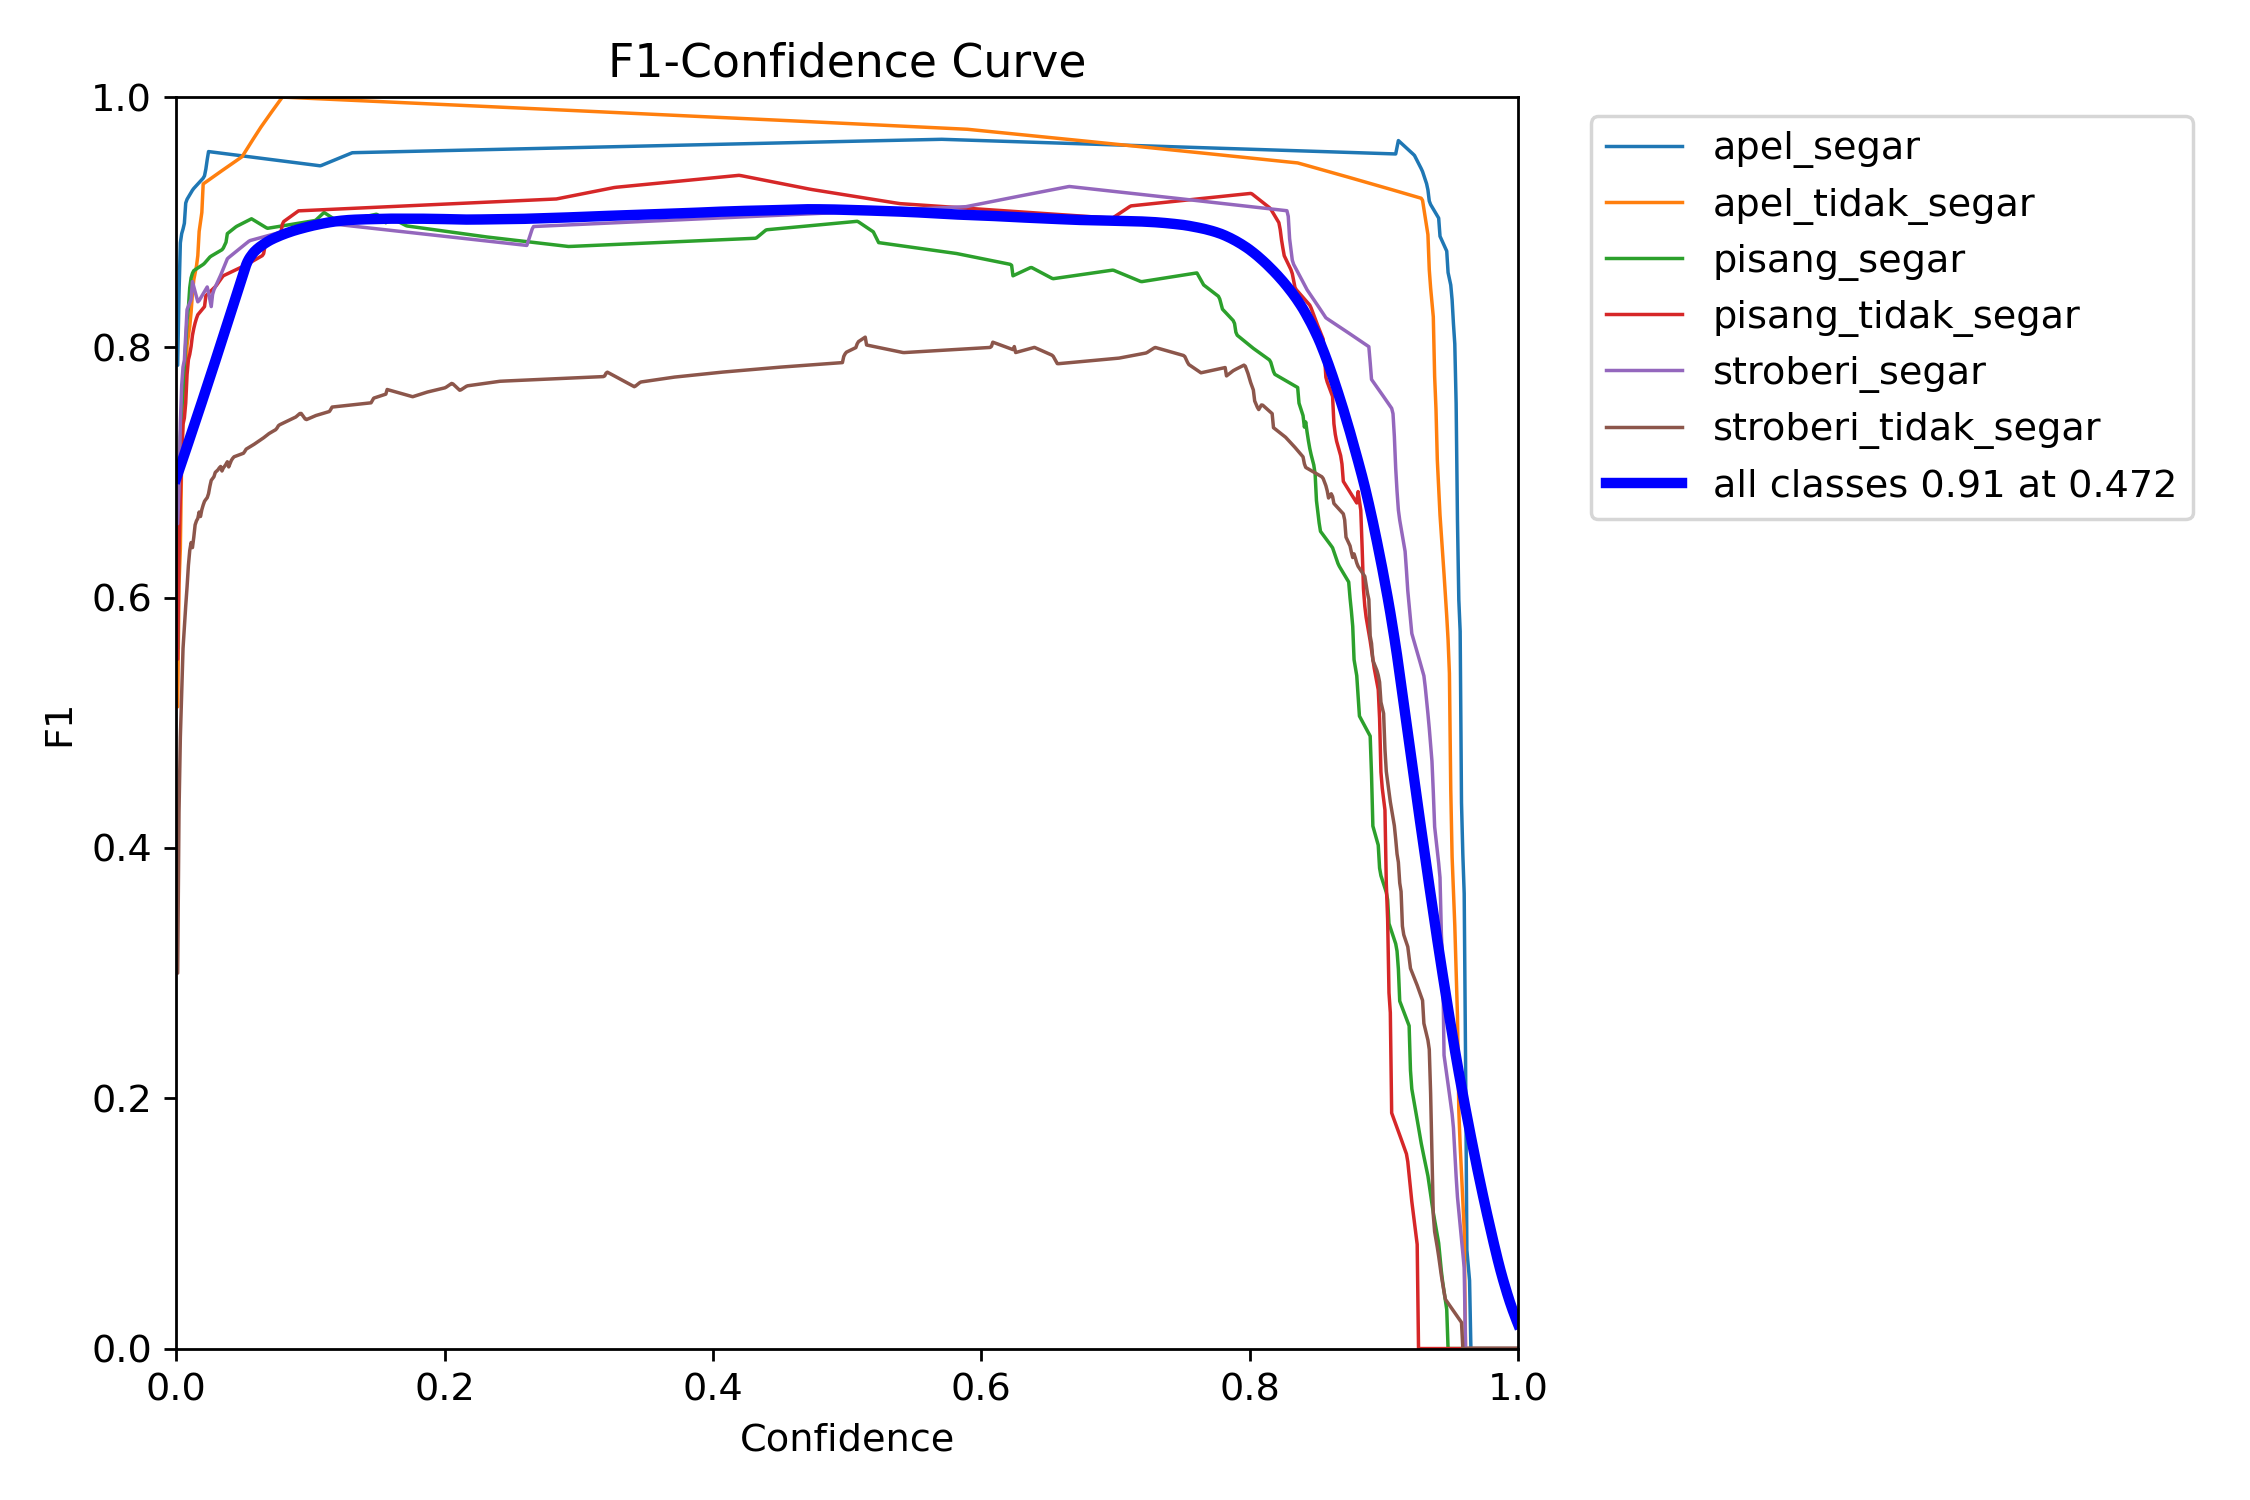

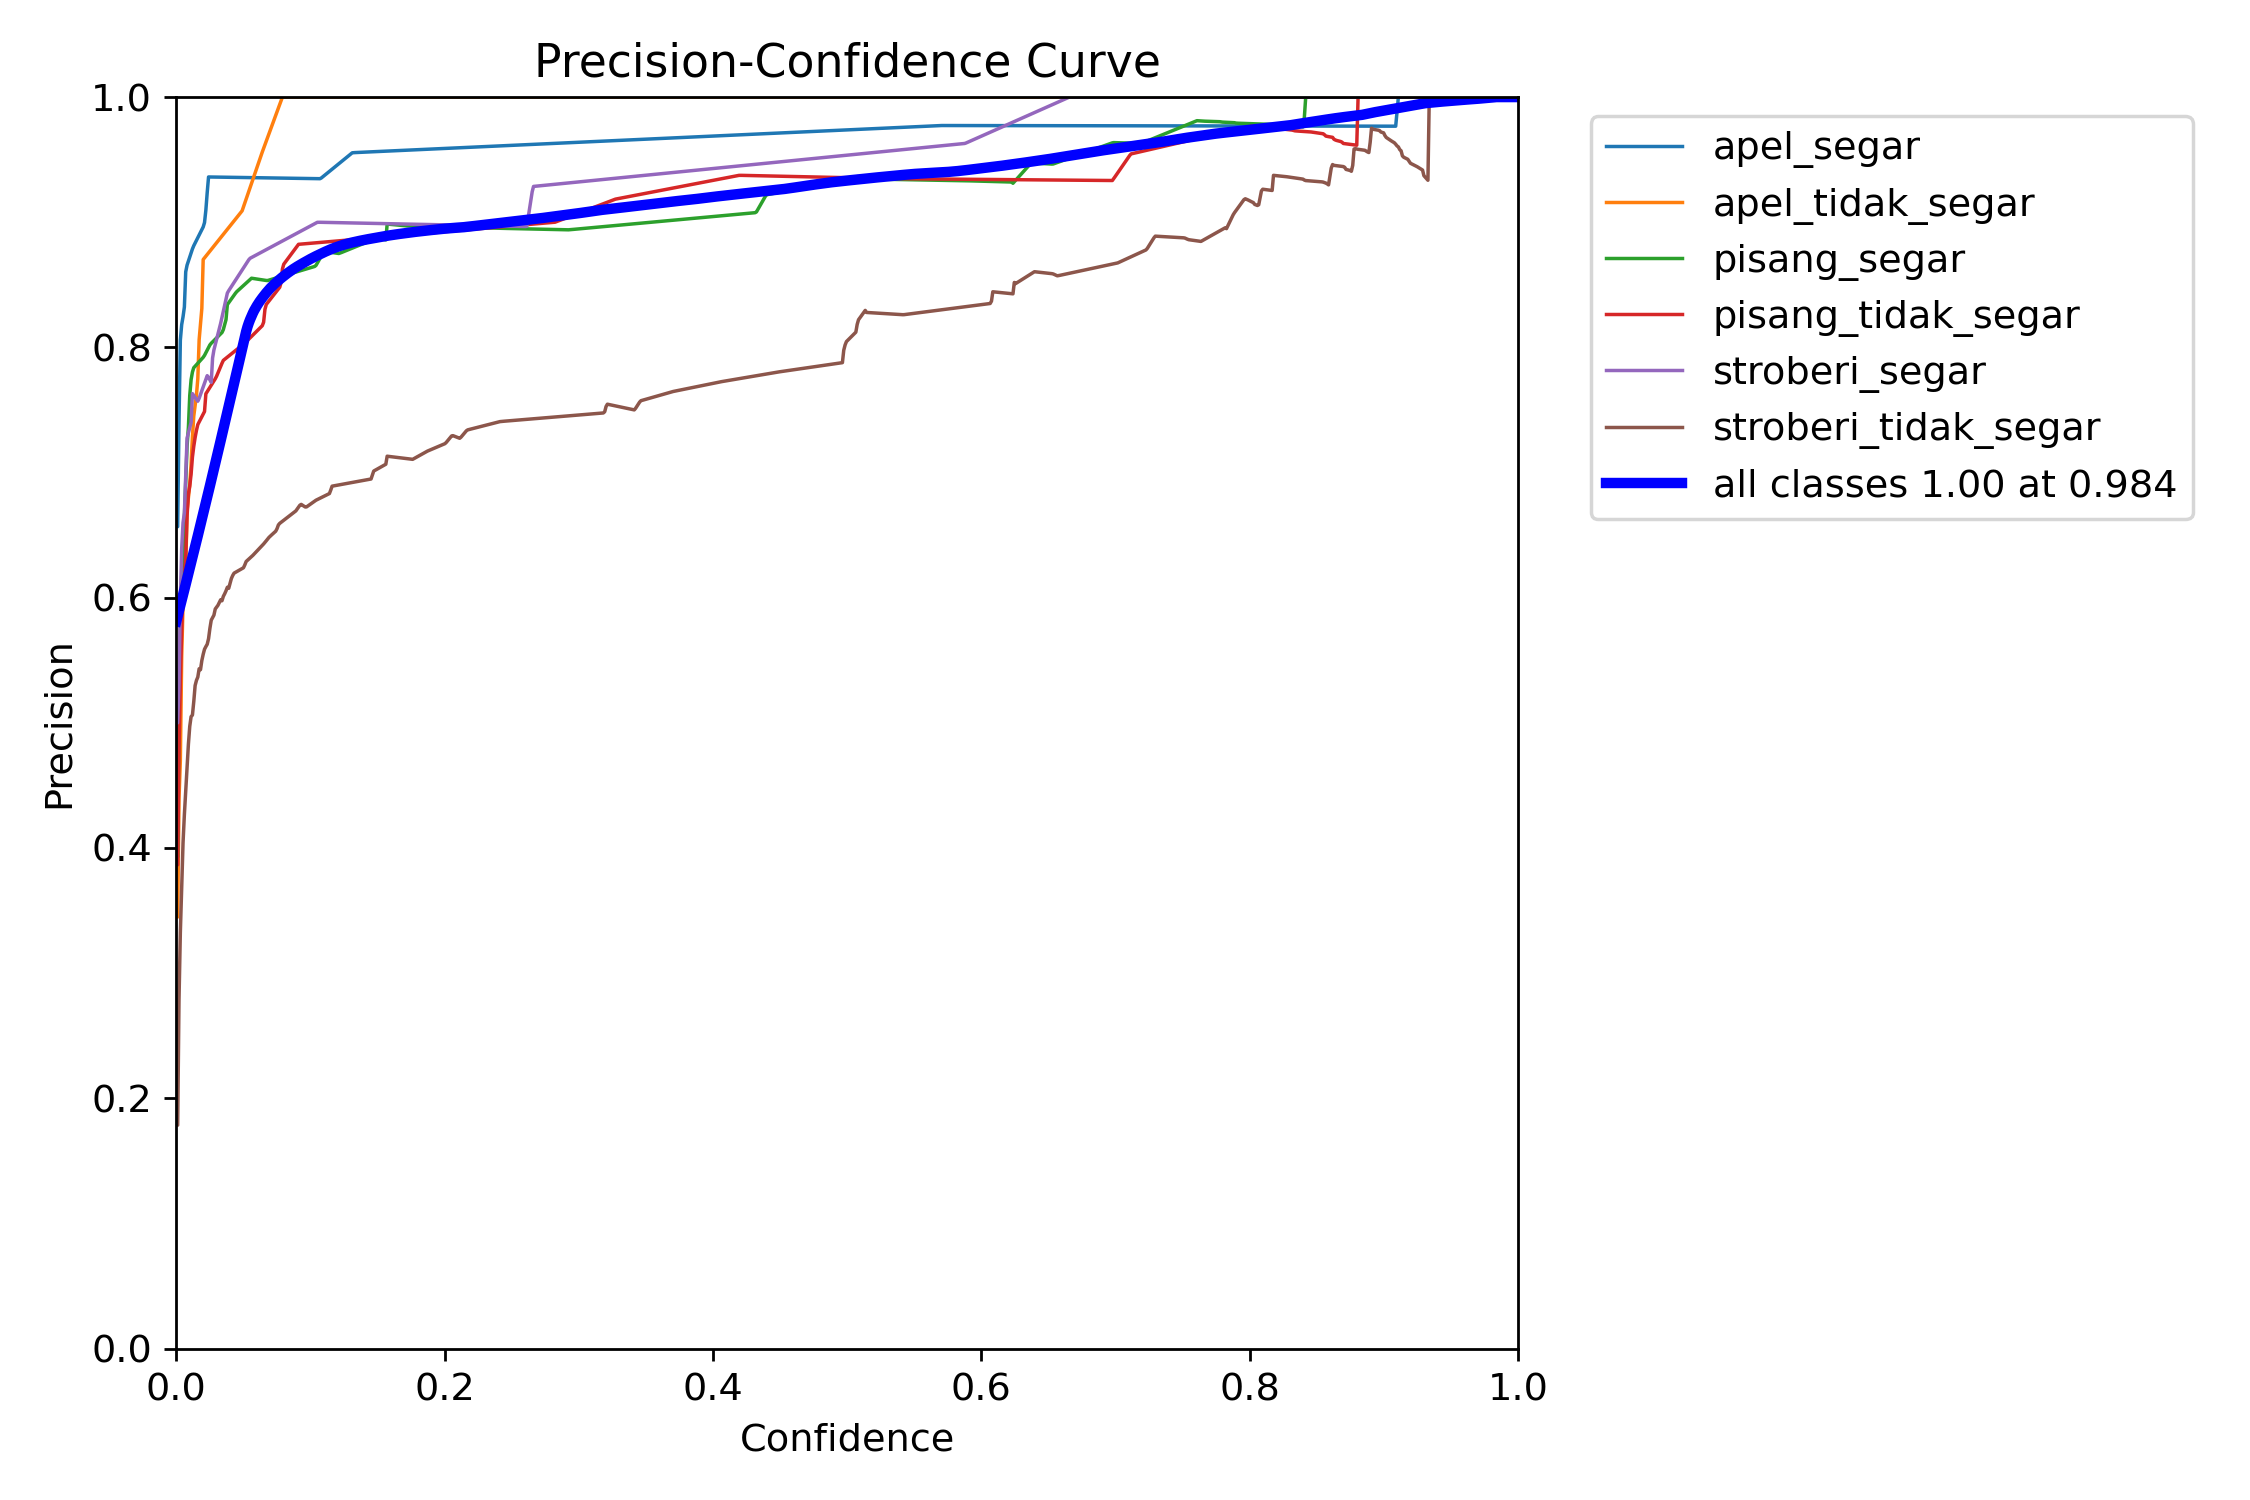

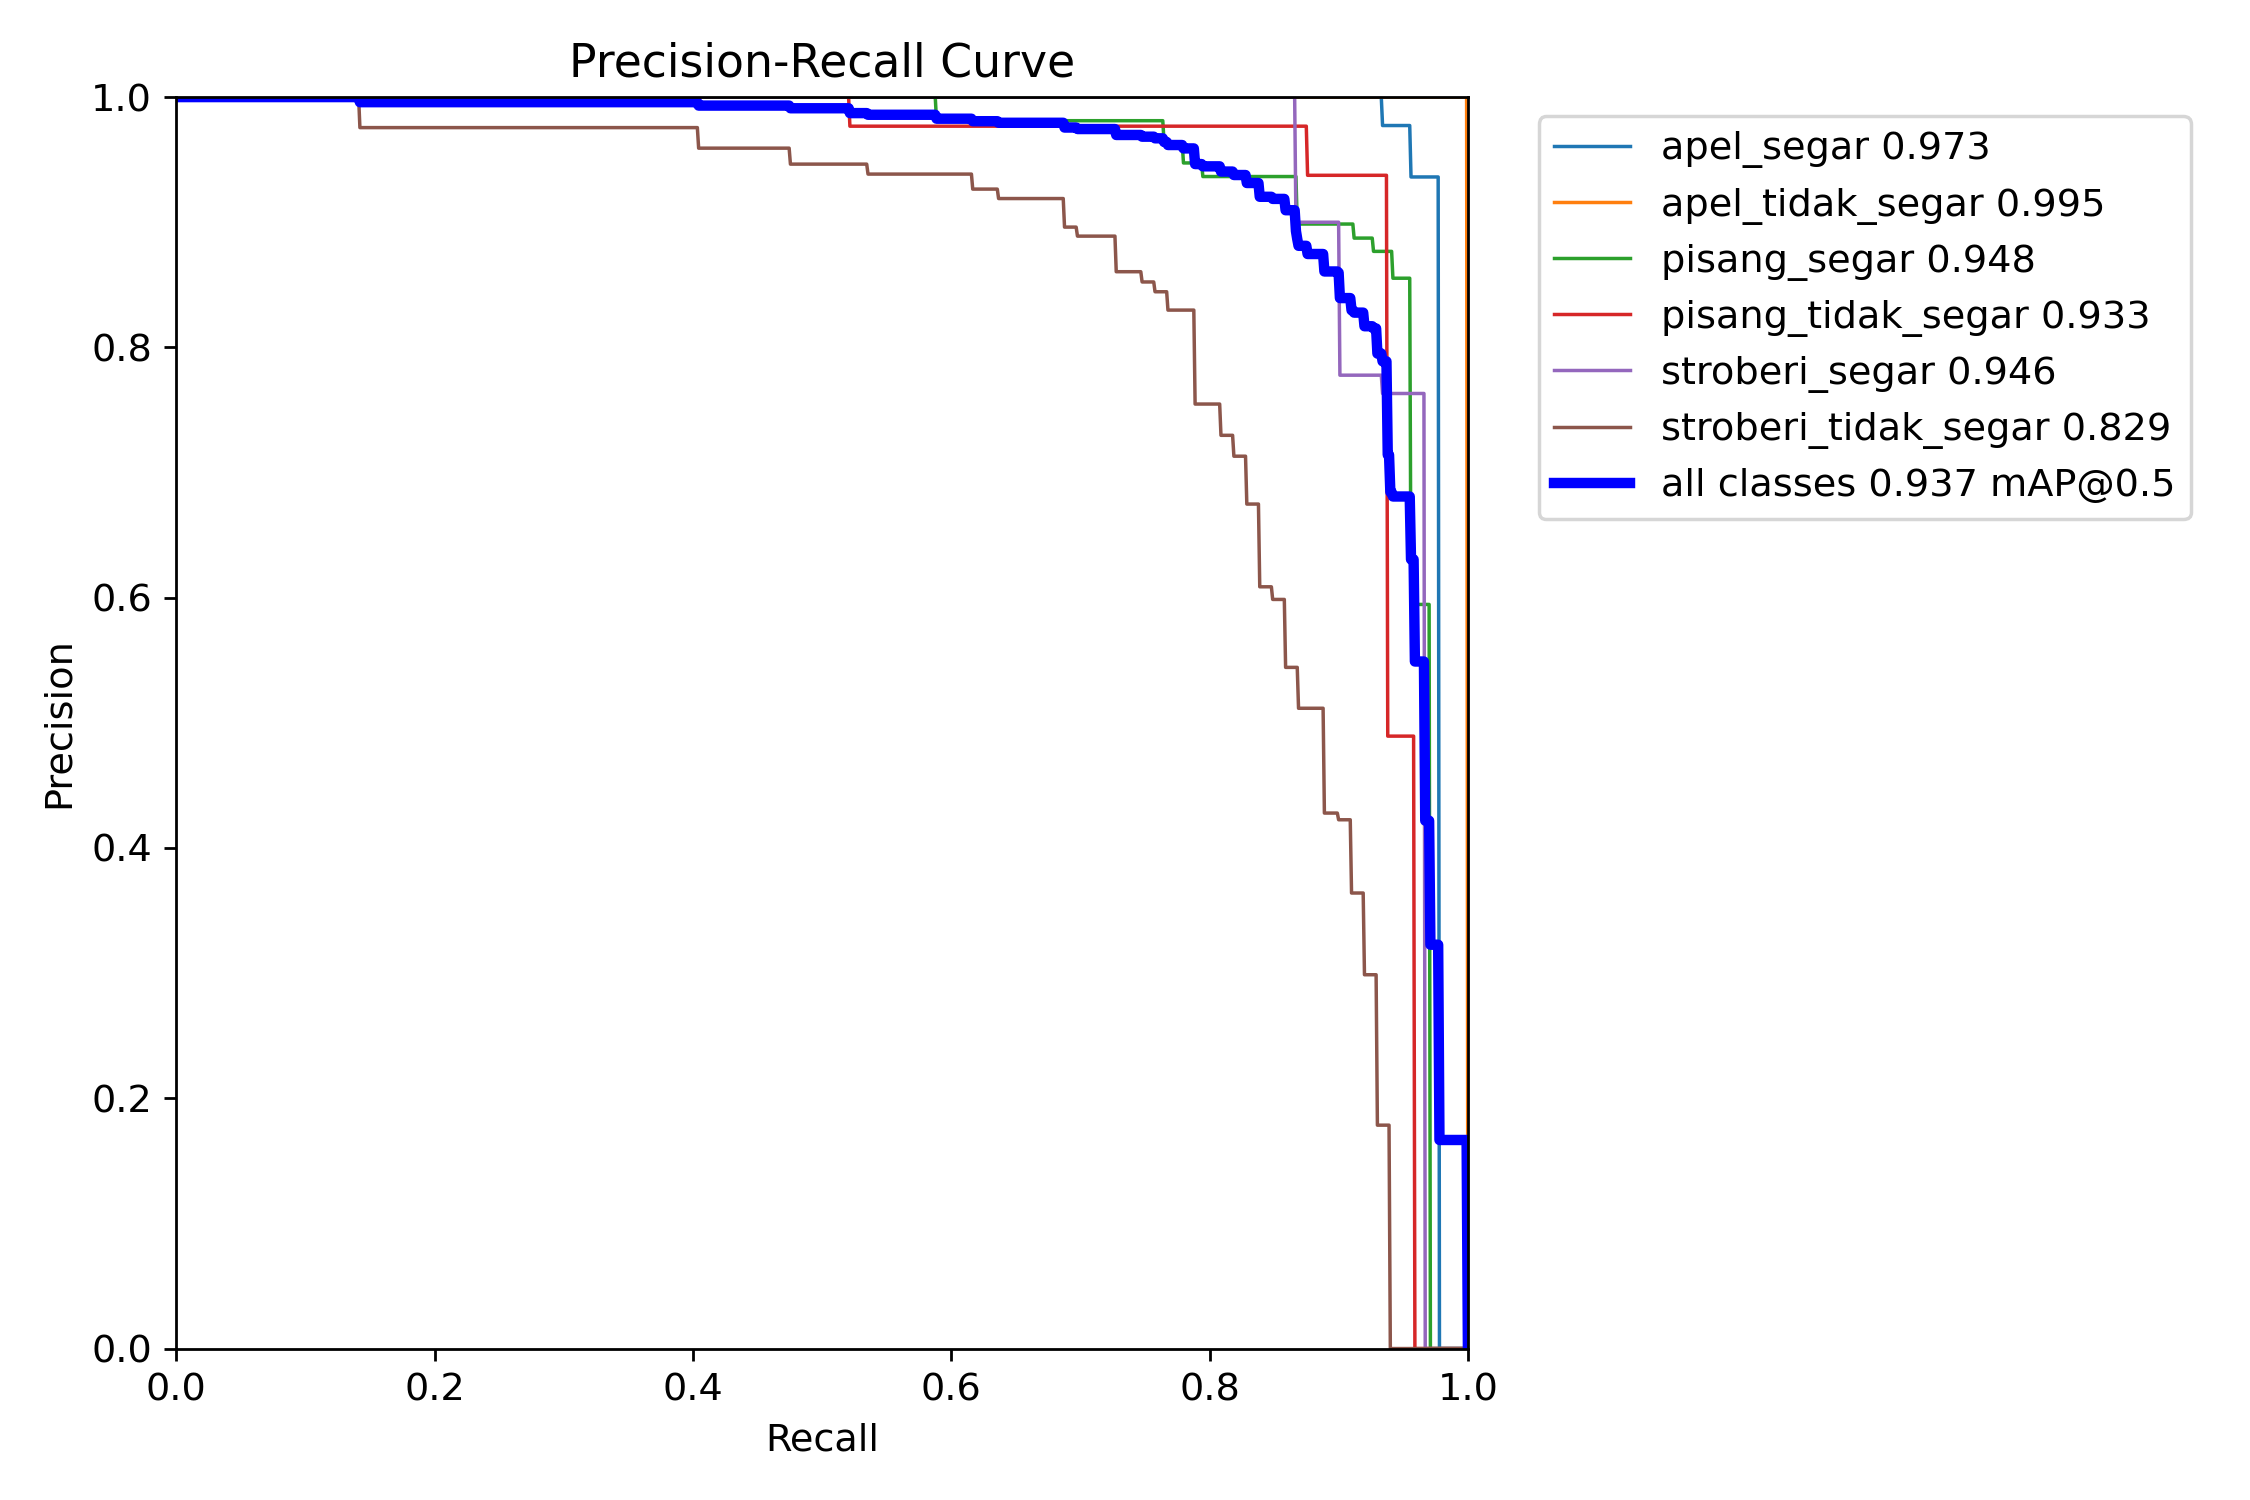

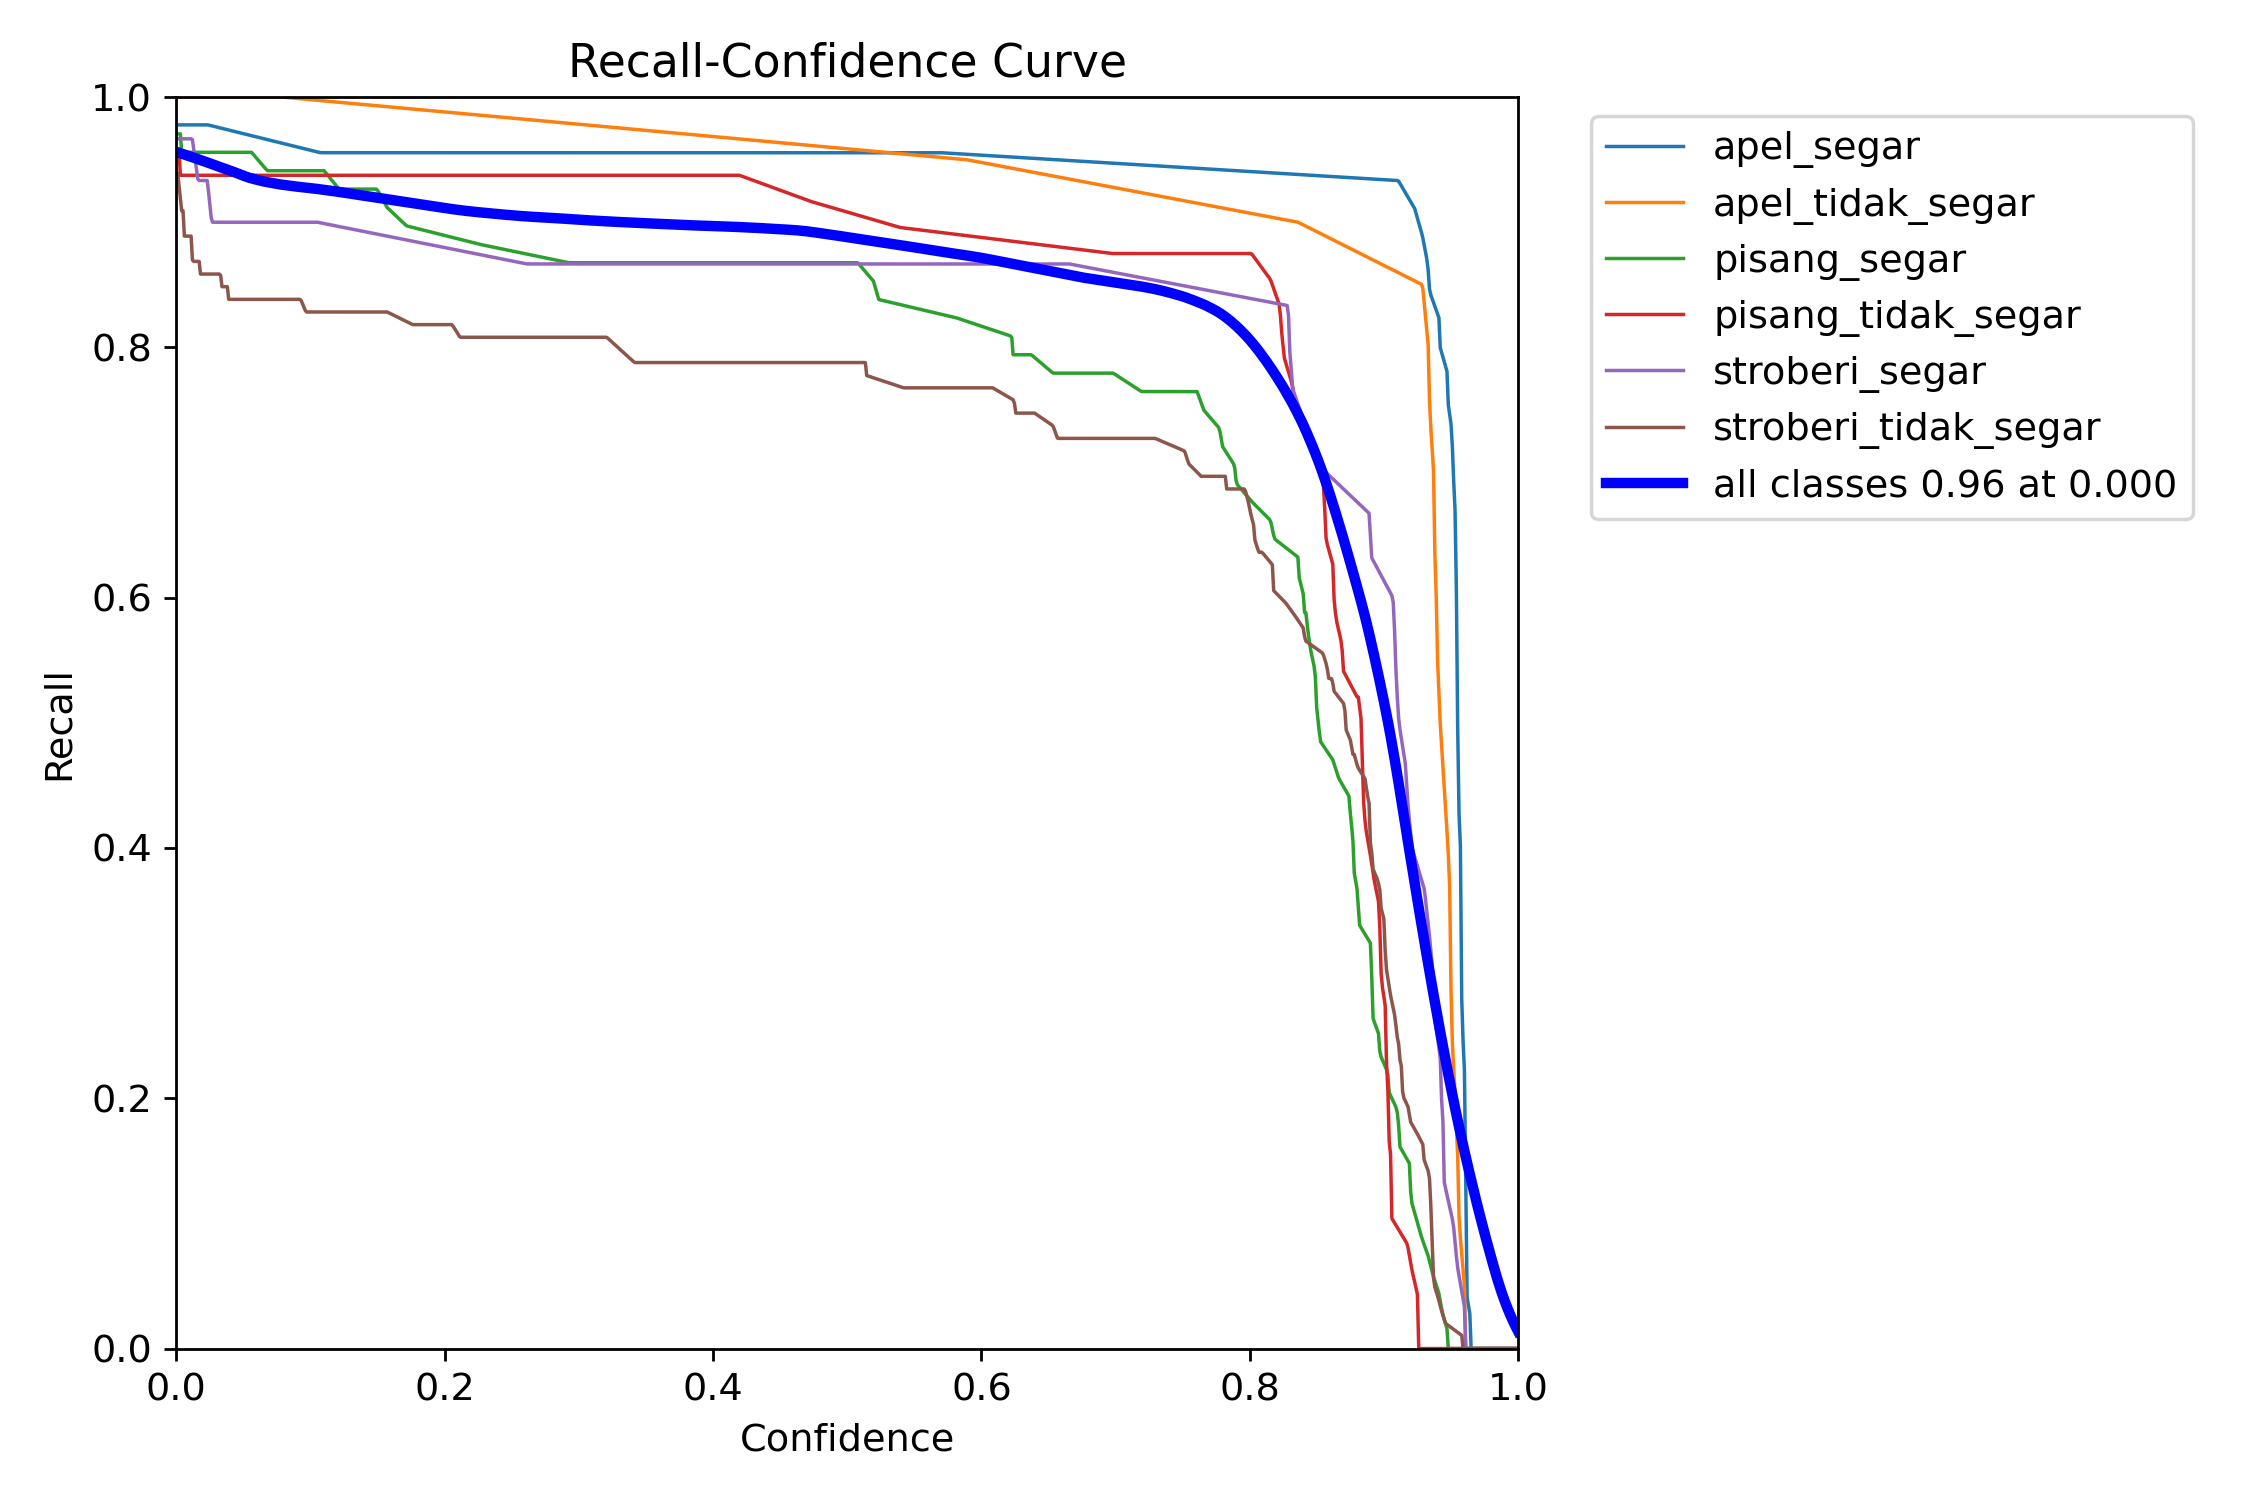

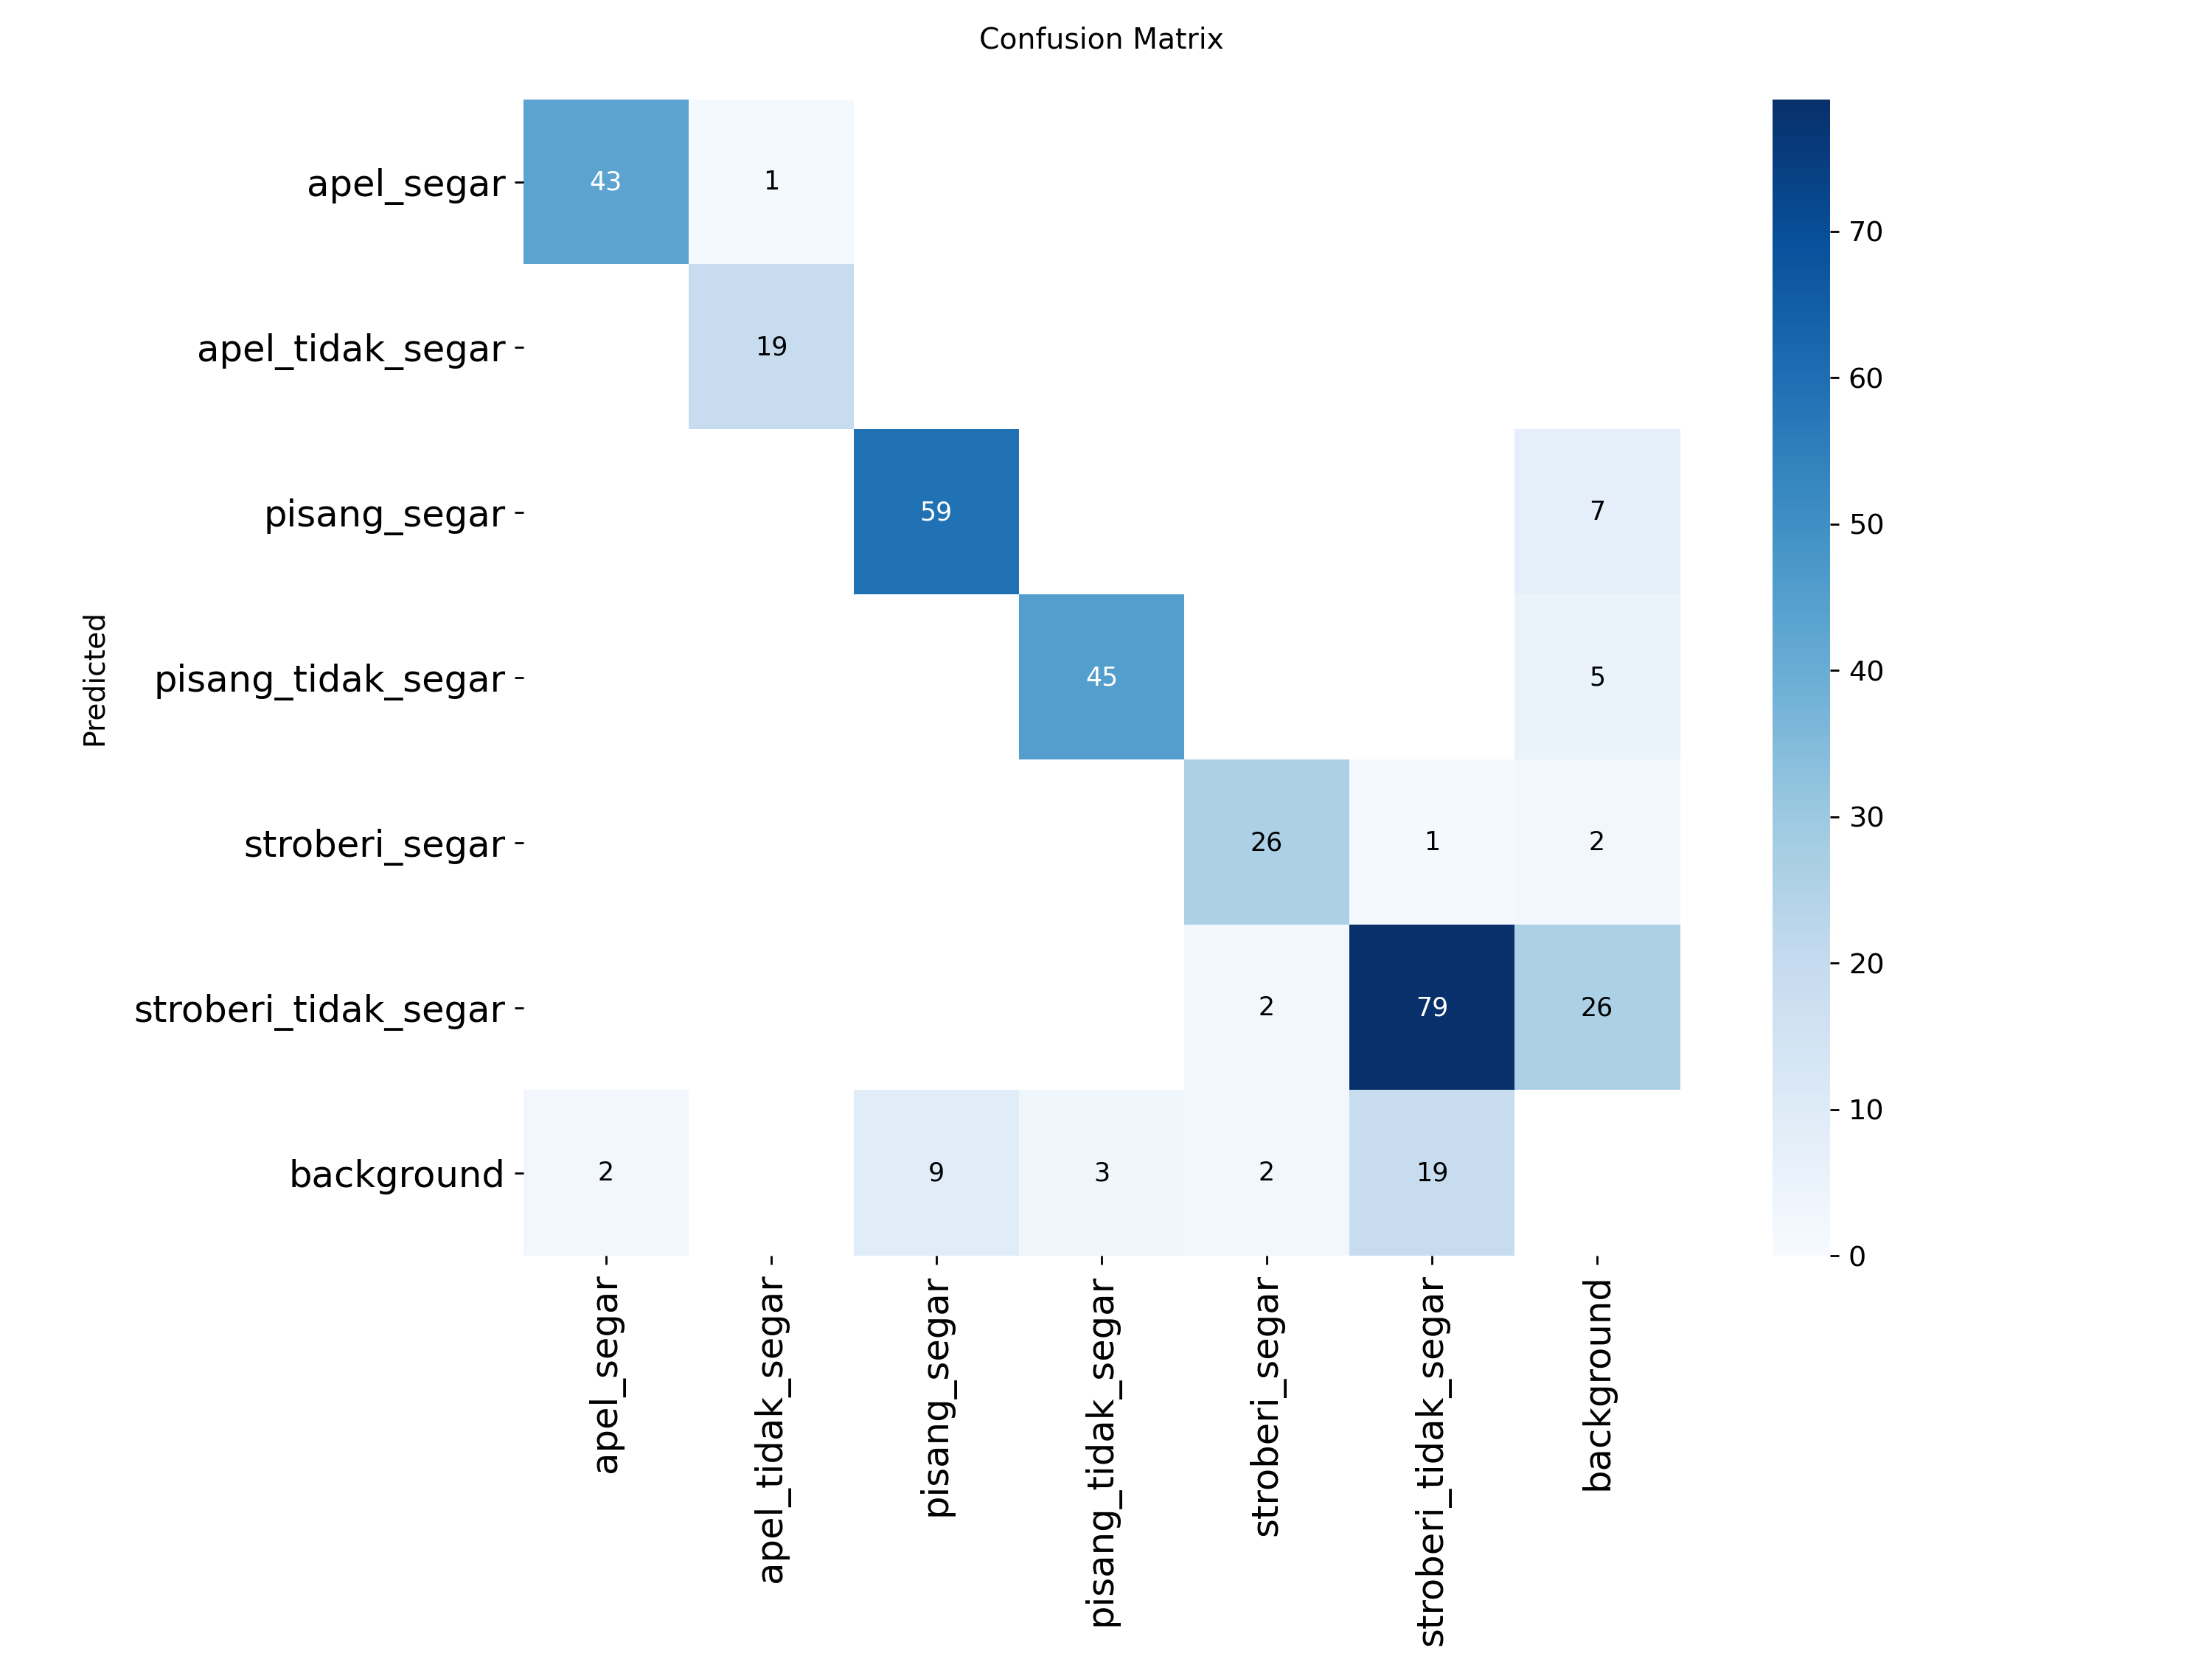

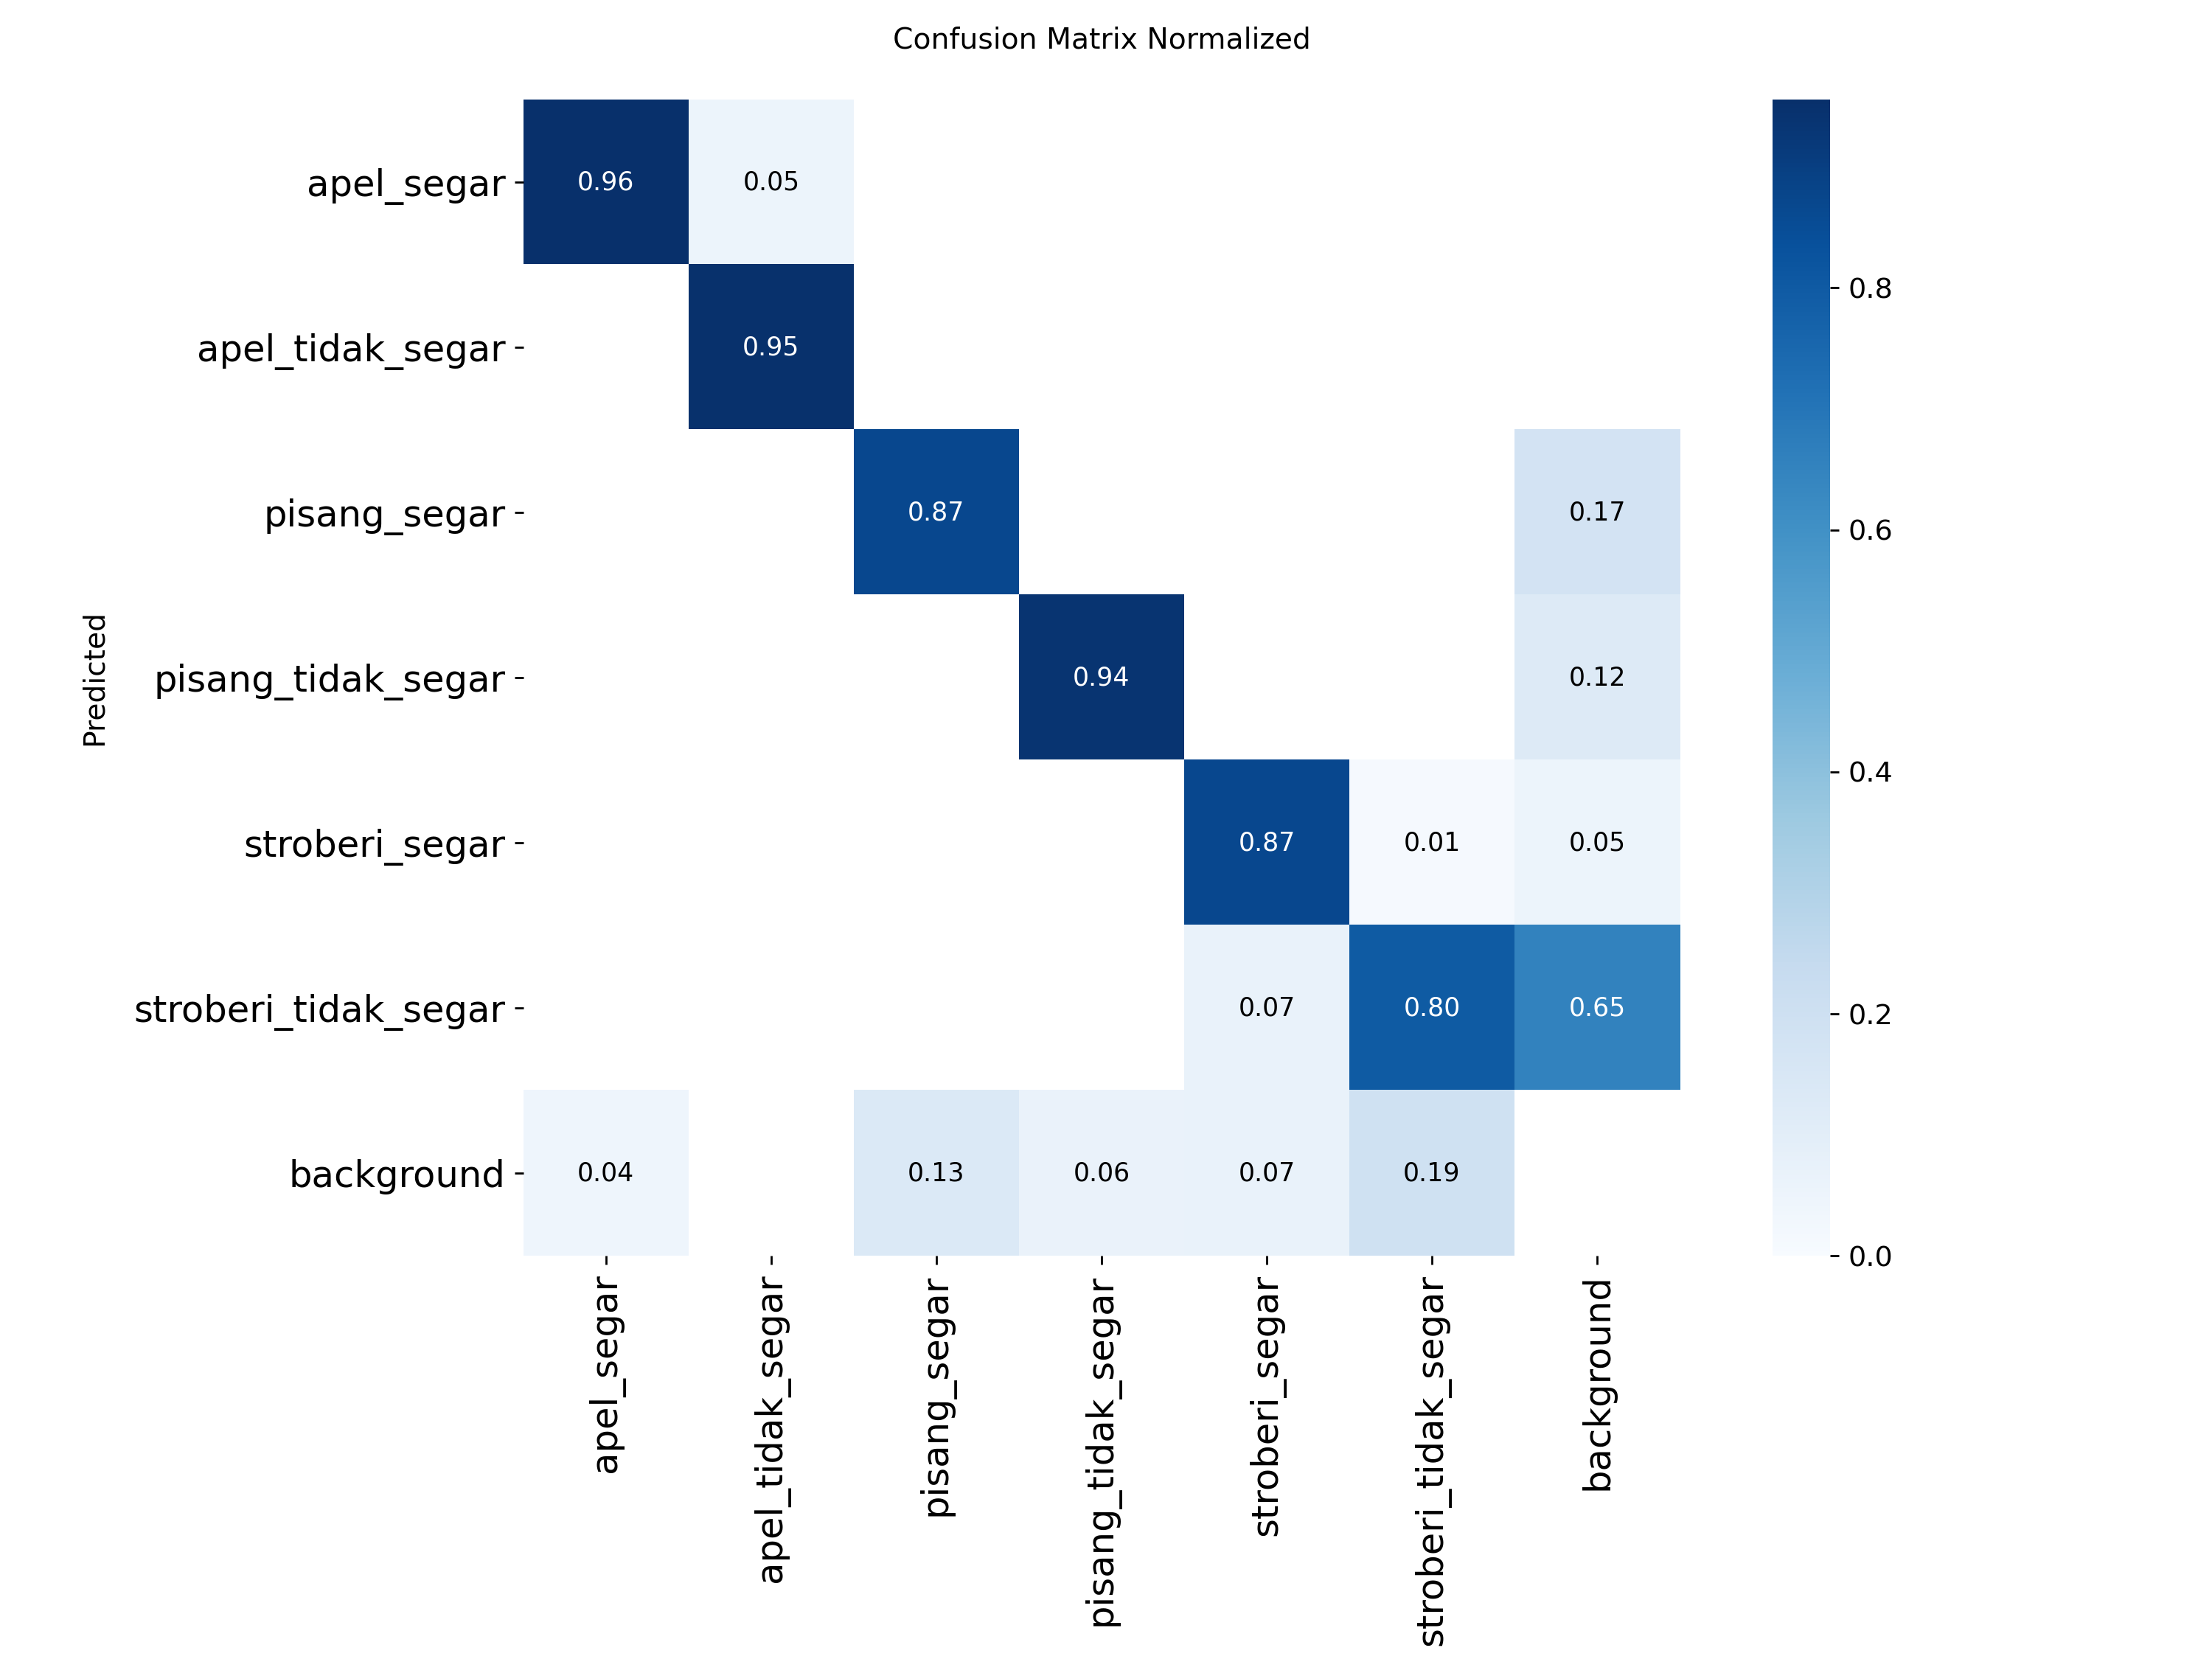

In [14]:
from IPython.display import Image, display

display(Image('/content/runs/detect/train/BoxF1_curve.png'))
display(Image('/content/runs/detect/train/BoxP_curve.png'))
display(Image('/content/runs/detect/train/BoxPR_curve.png'))
display(Image('/content/runs/detect/train/BoxR_curve.png'))
display(Image('/content/runs/detect/train/confusion_matrix.png'))
display(Image('/content/runs/detect/train/confusion_matrix_normalized.png'))

Download YOLO Model

In [12]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 9%)
  adding: train/ (stored 0%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/best.pt (deflated 9%)
  adding: train/weights/last.pt (deflated 9%)
  adding: train/val_batch0_pred.jpg (deflated 14%)
  adding: train/BoxP_curve.png (deflated 12%)
  adding: train/train_batch23401.jpg (deflated 15%)
  adding: train/val_batch0_labels.jpg (deflated 14%)
  adding: train/results.png (deflated 8%)
  adding: train/train_batch23400.jpg (deflated 8%)
  adding: train/BoxPR_curve.png (deflated 14%)
  adding: train/BoxF1_curve.png (deflated 9%)
  adding: train/train_batch1.jpg (deflated 6%)
  adding: train/results.csv (deflated 63%)
  adding: train/train_batch23402.jpg (deflated 8%)
  adding: train/val_batch1_labels.jpg (deflated 12%)
  adding: train/val_batch2_labels.jpg (deflated 13%)
  adding: train/BoxR_curve.png (deflated 9%)
  adding: train/confusion_matrix_normalized.png (deflated 19%)
  adding: train/train_batch0.jpg (deflated 12

In [13]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>